In [2]:
import torch

from thesis_code.datasets import get_SHD_dataloader
from thesis_code.networks import train, test, models
from thesis_code.plotting import plot_performance

In [3]:
dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [4]:
SHD_trainloader, input_dim, classes = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=True,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

SHD_testloader, _, _ = get_SHD_dataloader(
    batch_size=128,
    time_window=10000,
    train=False,
    shuffle=True,
    drop_last=True,
    re_download=False,
)

In [4]:
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

Test Accuracy before training is: 0.05193014705882353


Epoch 0:   2%|▏         | 1/63 [00:00<00:40,  1.53it/s, acc=8.59%, loss=4.58]

Epoch 0, Iteration 0 — Loss: 4.58, Acc: 8.59%


Epoch 0:  41%|████▏     | 26/63 [00:16<00:20,  1.76it/s, acc=6.25%, loss=3.24] 

Epoch 0, Iteration 25 — Loss: 3.24, Acc: 6.25%


...

Epoch 49, Iteration 25 — Loss: 2.99, Acc: 13.28%


Epoch 49:  81%|████████  | 51/63 [00:36<00:08,  1.44it/s, acc=14.06%, loss=3.05]

Epoch 49, Iteration 50 — Loss: 3.05, Acc: 14.06%


Epoch 49: 100%|██████████| 63/63 [00:44<00:00,  1.41it/s, acc=17.97%, loss=3.00]


Test Accuracy after training is: 0.13005514705882354


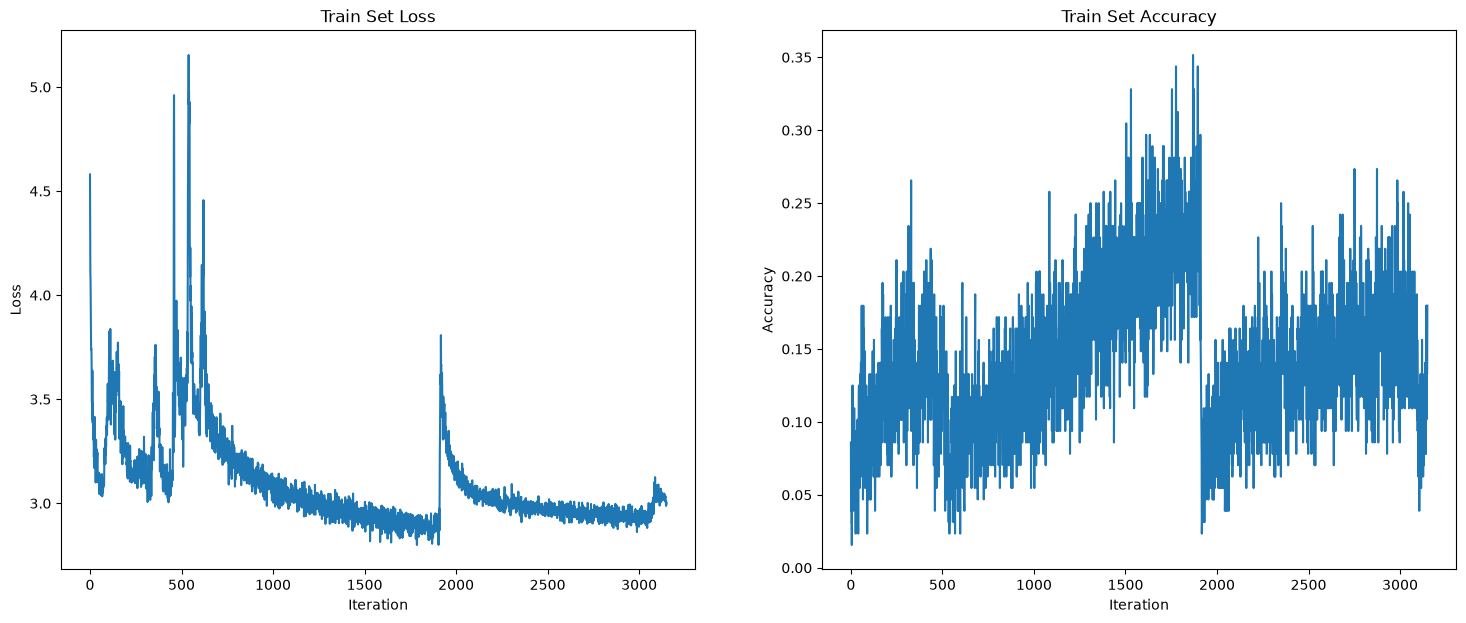

In [7]:
net = models.KaimingSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-4,
    n_epochs=50,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")

Test Accuracy before training is: 0.05330882352941176


Epoch 0:   2%|▏         | 1/63 [00:01<01:02,  1.00s/it, acc=3.12%, loss=4.67]

Epoch 0, Iteration 0 — Loss: 4.67, Acc: 3.12%


Epoch 0:  41%|████▏     | 26/63 [00:26<00:36,  1.01it/s, acc=8.59%, loss=3.33]

Epoch 0, Iteration 25 — Loss: 3.33, Acc: 8.59%


...

Epoch 9, Iteration 25 — Loss: 7.81, Acc: 6.25%


Epoch 9:  81%|████████  | 51/63 [00:53<00:12,  1.01s/it, acc=2.34%, loss=7.49] 

Epoch 9, Iteration 50 — Loss: 7.49, Acc: 2.34%


Epoch 9: 100%|██████████| 63/63 [01:06<00:00,  1.05s/it, acc=10.16%, loss=6.73]


Test Accuracy after training is: 0.058823529411764705


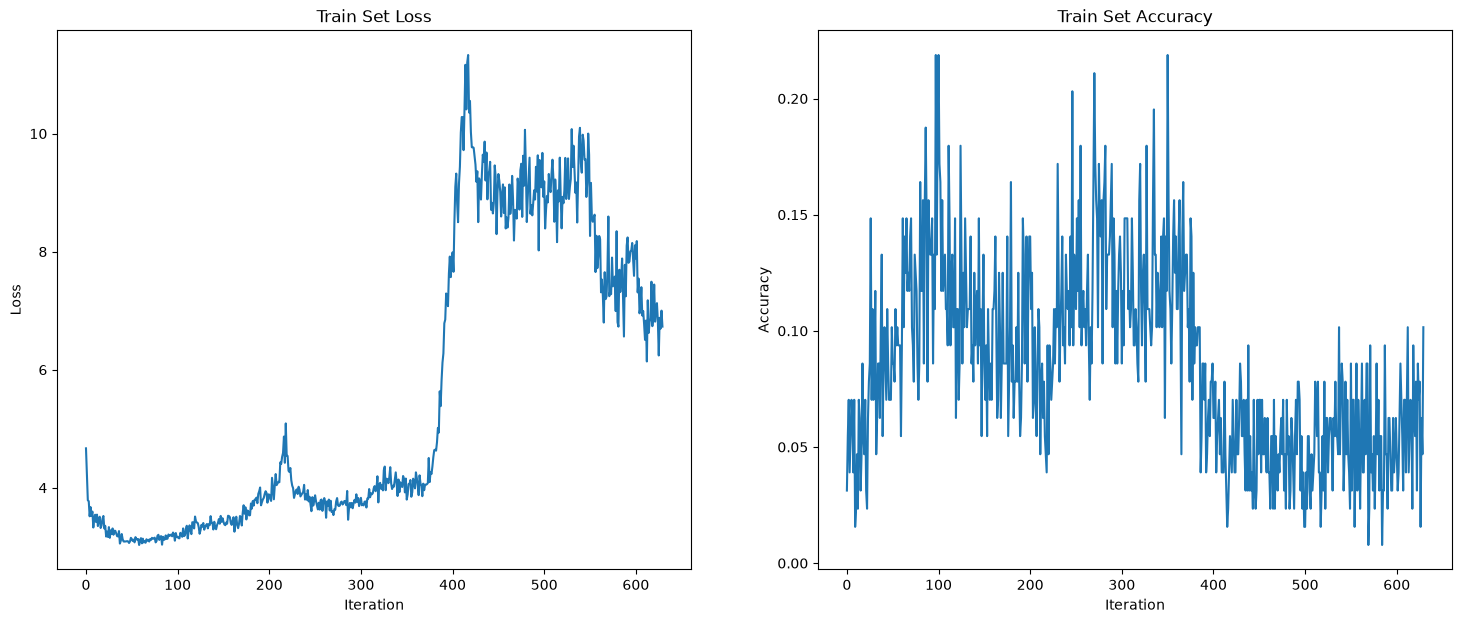

In [5]:
# To prevent catastrophic collapse due to exploding gradients like above:

import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

loss_fn = nn.CrossEntropyLoss(reduction='none')

def compute_loss(mem_rec, targets, device):
    loss_val = torch.zeros((1), dtype=torch.float, device=device)
    for mem_out in mem_rec:
        loss_val += loss_fn(mem_out, targets).mean() / len(mem_rec)
    return loss_val

def measure_accuracy(mem_rec, targets):
    _, idx = mem_rec.sum(dim=0).max(1)
    return np.mean((targets == idx).detach().cpu().numpy())

def test(net: nn.Module, device: torch.device, testloader: DataLoader, max_iters: int = None) -> float:
    with torch.no_grad():
        acc = 0
        net.eval()

        for i, (data, targets) in enumerate(testloader):
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)
            
            spk_rec, mem_rec = net(data)
            acc += measure_accuracy(mem_rec, targets)
            if max_iters is not None and i == max_iters:
                break

    return acc / len(testloader)

def train(net: nn.Module, device: torch.device, trainloader: DataLoader, lr: float = 1e-3, n_epochs: int = 1, max_iters: int = None) -> tuple[nn.Module, list, list]:
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, betas=(0.9, 0.999))

    loss_hist, acc_hist = [], []
    net.train()

    for epoch in range(n_epochs):
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch}")
        for i, (data, targets) in progress_bar:
            data, targets = data.to(device), targets.to(device)
            data = data.squeeze(2)

            spk_rec, mem_rec = net(data)
            loss_val = compute_loss(mem_rec, targets, device)

            optimizer.zero_grad()
            loss_val.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
            optimizer.step()

            loss_hist.append(loss_val.item())

            acc = measure_accuracy(mem_rec, targets)
            acc_hist.append(acc)

            progress_bar.set_postfix(loss=f"{loss_val.item():.2f}", acc=f"{acc * 100:.2f}%")

            if i % 25 == 0:
                tqdm.write(f"Epoch {epoch}, Iteration {i} — Loss: {loss_val.item():.2f}, Acc: {acc*100:.2f}%")

            if max_iters is not None and i == max_iters:
                break

    return net, loss_hist, acc_hist

net = models.KaimingSRNN(
    n_in=input_dim,
    ns_hidden=[256, 256],
    n_out=len(classes),
    beta=0.9,
).to(device)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy before training is: {accuracy}")

net_simple, loss_hist, acc_hist = train(
    net=net,
    device=device,
    trainloader=SHD_trainloader,
    lr=1e-4,
    n_epochs=10,
    max_iters=None,
)
plot_performance(loss_hist, acc_hist)

accuracy = test(
    net=net,
    device=device,
    testloader=SHD_testloader,
    max_iters=None,
)
print(f"Test Accuracy after training is: {accuracy}")